## Model Training

In this notebook, three main models are trained and their performance metrics is displayed.

We start by importing dependencies, loading data and best configurations chosen from feature selection.

In [1]:
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay, RocCurveDisplay)
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Load config
with open("models/best_config.json") as f:
    cfg = json.load(f)

# Load data
train_df = pd.read_csv("Dataset/train.csv")
test_df  = pd.read_csv("Dataset/test.csv")

train_df[cfg["input_field"]] = train_df[cfg["input_field"]].fillna("")
test_df[cfg["input_field"]]  = test_df[cfg["input_field"]].fillna("")

y_train = train_df["label"].values
y_test  = test_df["label"].values

print("Config:", json.dumps(cfg, indent=2))
print(f"\nTrain: {len(train_df)} | Test: {len(test_df)}")


Config: {
  "feature_type": "tfidf",
  "input_field": "content",
  "ngram_range": [
    1,
    2
  ],
  "best_C": 10.0,
  "max_features": 50000,
  "vector_size": 100
}

Train: 33043 | Test: 11015


Building feature matrix from the vectorizer selected from the previous task

In [2]:
# Load the saved vectorizer from Notebook 2
vectorizer = joblib.load("models/best_vectorizer.pkl")

# Transform using the already-fitted vectorizer (no re-fitting)
X_train = vectorizer.transform(train_df[cfg["input_field"]])
X_test  = vectorizer.transform(test_df[cfg["input_field"]])

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape : {X_test.shape}")
print(f"Feature type : sparse matrix (TF-IDF)")


X_train shape: (33043, 50000)
X_test shape : (11015, 50000)
Feature type : sparse matrix (TF-IDF)


TF-IDF vectorizer scanned every article in the training set and built a vocabulary of 50,000 most common words/phrases. This vocabulary is fixed and these 50,000 most common words are tracked if they exist in each article. If a word exists, the vector score is updated for the corresponding matrix index that represents the word in the vocabulary. So each sample has this 50,000 vocabulary score. Most of the vector scores for a single data sample are zero because each article contains fewer than 50,000 words/phrases.

Below is the vocabulary score of the top 10 features from the vectorizer for the first sample (index = 0)

In [3]:
row = X_train[0].toarray().flatten()
print("Top 10 features for the first training example:")
top_indices = np.argsort(row)[-10:][::-1]
feature_names = vectorizer.get_feature_names_out()
for idx in top_indices:
    print(f"{feature_names[idx]}: {row[idx]:.4f}")

Top 10 features for the first training example:
author: 0.2643
letter: 0.2467
writer: 0.2328
signed letter: 0.1985
stephen king: 0.1498
unequivocally: 0.1307
forceful: 0.1275
name: 0.1217
trump: 0.1192
conscience: 0.1106


### Logistic Regression

Next, the Logistic regression model is trained and performance metrics are displayed using comfusion matrix and 


Training Logistic Regression...

Logistic Regression Results:
  accuracy    : 0.9939
  precision   : 0.9928
  recall      : 0.9945
  f1          : 0.9937
  roc_auc     : 0.9996


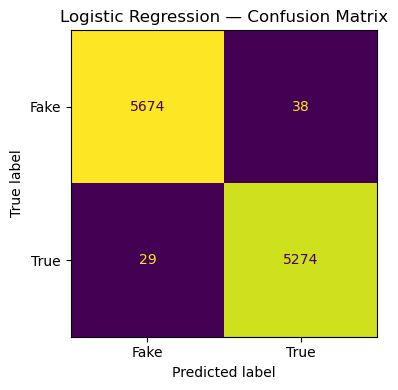

In [4]:
print("Training Logistic Regression...")
lr = LogisticRegression(C=cfg["best_C"], max_iter=1000, solver="lbfgs", n_jobs=-1)
lr.fit(X_train, y_train)

lr_preds  = lr.predict(X_test)
lr_proba  = lr.predict_proba(X_test)[:, 1]

lr_metrics = {
    "accuracy" : accuracy_score(y_test, lr_preds),
    "precision": precision_score(y_test, lr_preds),
    "recall"   : recall_score(y_test, lr_preds),
    "f1"       : f1_score(y_test, lr_preds),
    "roc_auc"  : roc_auc_score(y_test, lr_proba)
}

print("\nLogistic Regression Results:")
for k, v in lr_metrics.items():
    print(f"  {k:<12}: {v:.4f}")

# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, lr_preds,
    display_labels=["Fake", "True"], ax=ax, colorbar=False)
ax.set_title("Logistic Regression — Confusion Matrix")
plt.tight_layout()
plt.show()


### Support Vector Machine(SVM)

Next we train our SVM model using RBF kernel. Due to the large size of our dataset and `50,000` columns and the longer time it takes to train SVMs, we use `TruncatedSVD` to reduce the dimension of our sparse dataset to 300 columns. 

Reducing dimensions with TruncatedSVD (LSA)...
Reduced shape: (33043, 300)

Training SVM (RBF kernel)...

SVM (RBF) Results:
  accuracy    : 0.9923
  precision   : 0.9908
  recall      : 0.9932
  f1          : 0.9920
  roc_auc     : 0.9992


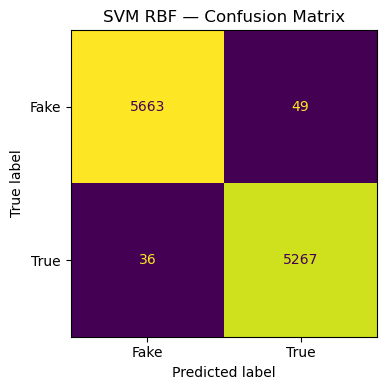

In [5]:
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import Normalizer

print("Reducing dimensions with TruncatedSVD (LSA)...")
svd = TruncatedSVD(n_components=300, random_state=42)
normalizer = Normalizer(norm="l2")

X_train_svd = normalizer.fit_transform(svd.fit_transform(X_train))
X_test_svd  = normalizer.transform(svd.transform(X_test))

print(f"Reduced shape: {X_train_svd.shape}")
print("\nTraining SVM (RBF kernel)...")

svm = SVC(kernel="rbf", C=cfg["best_C"], probability=True, random_state=42)
svm.fit(X_train_svd, y_train)

svm_preds = svm.predict(X_test_svd)
svm_proba = svm.predict_proba(X_test_svd)[:, 1]

svm_metrics = {
    "accuracy" : accuracy_score(y_test, svm_preds),
    "precision": precision_score(y_test, svm_preds),
    "recall"   : recall_score(y_test, svm_preds),
    "f1"       : f1_score(y_test, svm_preds),
    "roc_auc"  : roc_auc_score(y_test, svm_proba)
}

print("\nSVM (RBF) Results:")
for k, v in svm_metrics.items():
    print(f"  {k:<12}: {v:.4f}")

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, svm_preds,
    display_labels=["Fake", "True"], ax=ax, colorbar=False)
ax.set_title("SVM RBF — Confusion Matrix")
plt.tight_layout()
plt.show()


### Neural Network (PyTorch MLP)

Next we move to test a Neural Network model (PyTorch MLP). Here, we also use the dimension reduced dataset for our training.

We train our model for 20 epochs.

Training MLP...
  Epoch  5/20 — loss: 0.0239
  Epoch 10/20 — loss: 0.0090
  Epoch 15/20 — loss: 0.0055
  Epoch 20/20 — loss: 0.0043

MLP Results:
  accuracy    : 0.9897
  precision   : 0.9915
  recall      : 0.9870
  f1          : 0.9892
  roc_auc     : 0.9989


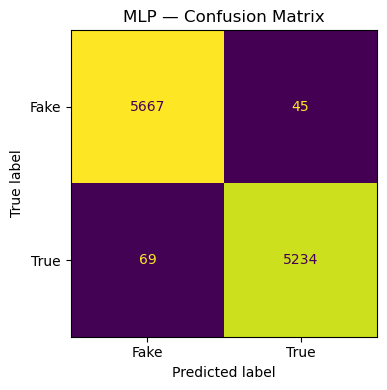

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Reuse SVD-reduced features from SVM for memory efficiency
X_train_t = torch.tensor(X_train_svd, dtype=torch.float32)
X_test_t  = torch.tensor(X_test_svd,  dtype=torch.float32)
y_train_t = torch.tensor(y_train,     dtype=torch.float32)
y_test_t  = torch.tensor(y_test,      dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t),
                          batch_size=64, shuffle=True)

# MLP architecture
class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x).squeeze(1)

model     = MLP(input_dim=X_train_svd.shape[1]).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCELoss()

# Training loop
print("Training MLP...")
for epoch in range(20):
    model.train()
    epoch_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    if (epoch + 1) % 5 == 0:
        print(f"  Epoch {epoch+1:>2}/20 — loss: {epoch_loss/len(train_loader):.4f}")

# Evaluation
model.eval()
with torch.no_grad():
    mlp_proba = model(X_test_t.to(device)).cpu().numpy()
mlp_preds = (mlp_proba >= 0.5).astype(int)

mlp_metrics = {
    "accuracy" : accuracy_score(y_test, mlp_preds),
    "precision": precision_score(y_test, mlp_preds),
    "recall"   : recall_score(y_test, mlp_preds),
    "f1"       : f1_score(y_test, mlp_preds),
    "roc_auc"  : roc_auc_score(y_test, mlp_proba)
}

print("\nMLP Results:")
for k, v in mlp_metrics.items():
    print(f"  {k:<12}: {v:.4f}")

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, mlp_preds,
    display_labels=["Fake", "True"], ax=ax, colorbar=False)
ax.set_title("MLP — Confusion Matrix")
plt.tight_layout()
plt.show()


### Model Comparison

The three models are then compared over their performance matrices.

=== Model Comparison ===
                     accuracy  precision  recall      f1  roc_auc
Logistic Regression    0.9939     0.9928  0.9945  0.9937   0.9996
SVM (RBF)              0.9923     0.9908  0.9932  0.9920   0.9992
MLP                    0.9897     0.9915  0.9870  0.9892   0.9989


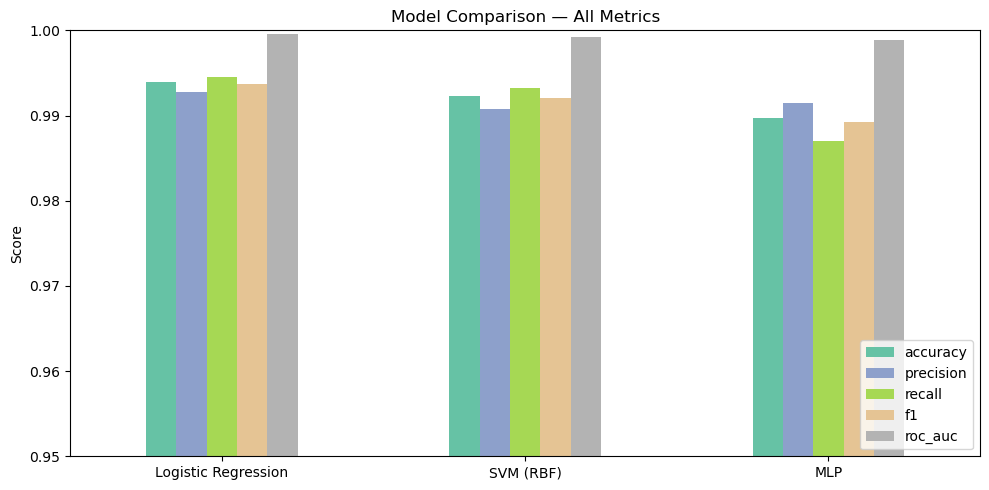

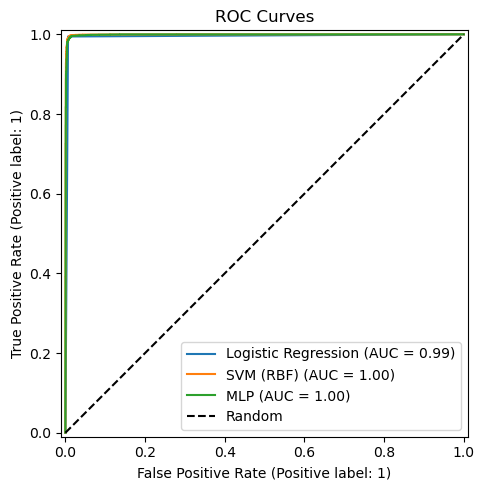

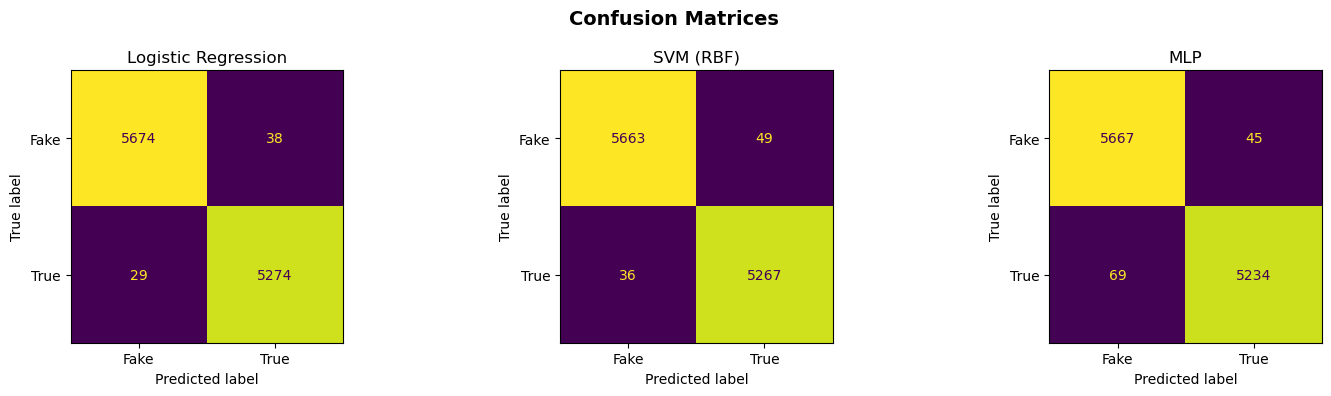

In [7]:
# Compile all metrics into one table
all_metrics = {
    "Logistic Regression": lr_metrics,
    "SVM (RBF)"          : svm_metrics,
    "MLP"                : mlp_metrics,
}

comp_df = pd.DataFrame(all_metrics).T.round(4)
print("=== Model Comparison ===")
print(comp_df.to_string())

# Bar chart comparison
fig, ax = plt.subplots(figsize=(10, 5))
comp_df.plot(kind="bar", ax=ax, ylim=(0.95, 1.0), rot=0, colormap="Set2")
ax.set_title("Model Comparison — All Metrics")
ax.set_ylabel("Score")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

# ROC curves — all three on one plot
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_test, lr_preds,  name="Logistic Regression", ax=ax)
RocCurveDisplay.from_predictions(y_test, svm_proba, name="SVM (RBF)",           ax=ax)
RocCurveDisplay.from_predictions(y_test, mlp_proba, name="MLP",                 ax=ax)
ax.set_title("ROC Curves")
ax.plot([0,1],[0,1],"k--", label="Random")
ax.legend()
plt.tight_layout()
plt.show()

# Side-by-side confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, preds) in zip(axes, [
    ("Logistic Regression", lr_preds),
    ("SVM (RBF)",           svm_preds),
    ("MLP",                 mlp_preds)
]):
    ConfusionMatrixDisplay.from_predictions(y_test, preds,
        display_labels=["Fake","True"], ax=ax, colorbar=False)
    ax.set_title(name)
plt.suptitle("Confusion Matrices", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


We see that our models are very closely ranked. However, the highest performance seen on all metics is the `Logistic Regression` model.

In [8]:
# picking best model by F1
best_name = comp_df["f1"].idxmax()
print(f"Best model by F1: {best_name} ({comp_df.loc[best_name, 'f1']:.4f})")


Best model by F1: Logistic Regression (0.9937)


### Saving the best model

In [9]:
import os

os.makedirs("models", exist_ok=True)

joblib.dump(lr, "models/best_model.pkl")
meta = {"model_type": "logistic_regression", "file": "models/best_model.pkl"}

# Save model metadata
meta["best_f1"] = comp_df.loc[best_name, "f1"]
with open("models/best_model_meta.json", "w") as f:
    json.dump(meta, f, indent=2)

print("Saved artifacts:")
for k, v in meta.items():
    print(f"  {k}: {v}")


Saved artifacts:
  model_type: logistic_regression
  file: models/best_model.pkl
  best_f1: 0.9937
